<table style="color:green">
  <tr><td><b>Cours</b></td><td>INF8111 - Fouille de données / Data Mining</td></tr>
  <tr><td><b>Session</b></td><td>Été 2026</td></tr>
  <tr><td><b>TP</b></td><td>TP3 - Fouille de réseaux sociaux / Mining of social networks</td></tr>
  <tr><td><b>Membre 1</b></td><td>DUVAL, Thomas — 2152675</td></tr>
  <tr><td><b>Membre 2</b></td><td>BOUSLAH, Soumeya — 2511549</td></tr>
  <tr><td><b>Membre 3</b></td><td>FAYE, Ousmane — 2490131</td></tr>
</table>


## Instructions de remise / Submission

Vous devez remettre dans la boîte de remise sur moodle:

1. ce fichier nommé TP3\_NomDuMembre1\_NomDuMembre2\_NomDuMembre3.ipynb

**N.B**: Assurez-vous que tous les résultats soient lisibles lorsque le notebook est ouvert.

Ce notebook être remis avant le **25 juin 2026 à 23h59**. Tout travail en retard sera pénalisé d’une valeur de 10\% par jour ouvrable de retard.

## Barème

Partie 1: 10 points

Partie 2: 6 points

Partie 3: 4 points

Pour un total de 20 points.


---

## Submission

You must put back in the submission box on moodle:

1. this file renamed TP3\_NomDuMembre1\_NomDuMembre2\_NomDuMembre3.ipynb

**N.B**: Make sure that all results are there when you open your notebook.

Everything must be submitted before **June 25th 2026 at 23h59**. Any late work will be penalized with a value of 10% per open day of delay.

## Barème
Part 1: 10 points

Part 2: 6 points

Part 3: 4 points

For a total of 20 points.


## Réseaux sociaux / Social Networks
Les réseaux sociaux occupent une grande partie de nos vies. Tout au long de sa vie, chaque personne appartient à différentes communautés. Avec la récupération de ces informations par les différents réseaux sociaux, les data-analystes ont voulu exploiter ces données. C'est un domaine relativement nouveau qui est en pleine croissance avec de nombreux impacts, notamment sur la publicité et les systèmes de recommandation.

### But
Le but de ce TP est de vous donner un aperçu de l'analyse de réseau social.

Dans la première partie, vous implémenterez un algorithme de détection de communautés dans un réseau social nommé LPAm+. Cet algorithme a été proposé par [X. Liu et T. Murata en 2010](https://www.sciencedirect.com/science/article/pii/S0378437109010152).

Dans la deuxième partie, vous trouverez les personnes avec le plus d'influence dans leur réseau social.

Pour les deux parties, nous vous fournissons les CSV contenant les réseaux sociaux à analyser.

---

## Social networks
Social networks are a major component of the human life. Each person belongs throughout their life to different communities. With the aggregation of information on various online social media platforms, data analysts were interested in exploiting its data. It is a relatively new field that is growing with impacts on several aspects such as advertising and recommendation systems.


### Goal
The purpose of this lab is to give you an overview of social network analysis.

In the first part, you will implement an algorithm for detecting communities in a social network called LPAm+. This algorithm was proposed by [X. Liu and T. Murata in 2010](https://www.sciencedirect.com/science/article/pii/S0378437109010152).

In the second part, you will find the people with the most influence in their social network.

For both parts, we provide you with the CSV containing the social networks to be analysed.

# 1. LPAm+ (10 points)

## Détection de communauté
La détection de communauté dans un réseau social est une manipulation fréquente lors de l'analyse d'un réseau. Une méthode de clustering est utilisée pour regrouper les personnes dans des communautés selon leurs liens.

## LPAm+
Dans cette partie, vous devez implémenter l'algorithme LPAm+ pour détecter les communautés parmi les personnages de l'univers cinématographique Marvel (MCU, en anglais). Vous devez utiliser les CSVs *nodes* et *edges* pour cela.

Cet algorithme consiste à propager les étiquettes dans le réseau selon une règle d'évaluation optimisant la modularité du réseau. Lorsque l'algorithme atteint un optimum local, il regarde s'il peut fusionner deux communautés pour augmenter la modularité du réseau. L'algorithme choisit toujours la combinaison la plus avantageuse. Si une combinaison est trouvée, la propagation des étiquettes est refaite. L'algorithme continue tant qu'il peut améliorer la modularité. Vous pouvez lire l'article mentionné plus haut pour plus de détails, mais cela n'est pas nécessaire puisque vous allez être guidé tout le long du TP.

Pour faciliter la représentation du réseau, nous vous proposons d'utiliser la librairie networkx. La documentation est disponible [ici](https://networkx.github.io/documentation/stable/tutorial.html).



---

## Community detection
Community detection in a social network is a frequent manipulation when analysing a network. A clustering method is used to bring people together in communities according to the links between them.


## LPAm+
In this part, you will implement the LPAm+ algorithm to detect the communities among the characters of the Marvel Cinematic Universe (MCU). You must use the nodes and edges csv for this.

This algorithm consists in propagating the labels in the network according to an evaluation rule optimizing the modularity of the network. When the algorithm reaches a local optimum, it checks whether it can combine two communities to increase the modularity of the network. The algorithm always chooses the most advantageous combination. If a combination is found, the propagation of the labels is redone. The algorithm continues until it is no longer able to increase modularity. You can read the article mentioned above for more details, but you do not need to, as you will be guided throughout the TP.


To help you represent a network, we suggest that you use the networkx package.You can read more about the package [here](https://networkx.github.io/documentation/stable/tutorial.html).

In [1]:
# vous pouvez bien sûr utiliser anaconda pour installer les packages

# !pip3 install --user numpy
# !pip3 install --user pandas
# !pip3 install --user matplotlib
# !pip3 install --user networkx

In [ ]:
# vérifions si les libraries sont bien installés

import networkx
print('networkx: {}'.format(networkx.__version__))

import matplotlib
print('matplotlib: {}'.format(matplotlib.__version__))

networkx: 3.6.1
matplotlib: 3.11.0


In [4]:
import numpy as np
import networkx as nx
import random
import itertools
import math

random.seed(42)
np.random.seed(42)

class LPAmPlus:
    """
    Contructor
    """
    def __init__(self, graph):
        """
        graph gives the graph on which the algorithm will be applied;
        """
        self.graph = graph

        """
        Assign a label to each node
        """
        self.nodes = list(graph.nodes()) # on stocke les sommets du graphe

        # sert à obtenir l'indice d'un sommet à partir de son nom comme clef
        self.idx = {node: i for i, node in enumerate(self.nodes)}

        # on stocke la matrice de modularité du graphe
        # elle ne changer pas durant l'algorithme car elle dépend uniquement de la structure du graphe
        # donc des arêtes et des degrés des sommets, qui ne changent pas (ne dépend pas des labels)
        self.B = nx.modularity_matrix(graph, nodelist=self.nodes)

        # on stocke le nombre d'arêtes du graphe
        self.m = graph.number_of_edges()

        # initilisation des labels avec la position du sommet (index)
        for i,n in  enumerate(self.nodes):
            graph.nodes[n]['label'] = i

        """
        labels gives all the communities present in the network
        """
        self.labels = list(range(len(self.nodes)))

        # notons qu'au début chaque sommet est dans sa propre communauté, comme l'exige
        # l'énoncé de LPAM, mais la liste de communautés diminuera au fur et à mesure
        # que les sommets seront regroupés


    """
    Term to optimize when replacing labels
    """
    def label_evaluation(self, current_node, new_label):
        # évaluation d'un label pour un sommet donné, en utilisant la formule de modularité
        # autrement dit, à quel point le sommet contribuerait à la modularité si on lui
        # assignait le label new_label
        x = self.idx[current_node] # on récupère l'indice du sommet
        total = 0 # on initialise la somme à 0
        for u in self.nodes:
            if u == current_node:
                continue # on ne considère pas le sommet lui même dans la somme
            if self.graph.nodes[u]['label'] == new_label: # on ne considère que les sommets qui ont le label new_label
                total += self.B[self.idx[u], x] # on ajoute la contribution de ce sommet à la somme
                # notons qu'on ne divise pas par m dans la formule de modularité,
                # car on s'intéresse à la contribution relative d'un label par rapport à un autre,
                # et le facteur 1/m serait commun à tous les labels, donc n'affecterait pas le choix du label optimal
        return total

    """
    Function to choose the new label for a node
    """
    def update_label(self, current_node):
        # on cherche le label qui maximise la contribution à la modularité pour le sommet current_node
        # essentiellement on va choisir le label avec la plus grande valeure calculée par label_evaluation
        candidates = {self.graph.nodes[v]['label'] for v in self.graph.neighbors(current_node)} # on considère les labels des voisins du sommet
        # on fait ce choix car les étiquettes non-voisinnes donneront toujours des contributions négatives en raison de la formule de modularité, donc on peut les ignorer
        candidates.add(self.graph.nodes[current_node]['label']) # le label actuel est aussi un candidat car son résultat pourrait être meilleur
        # que les autres labels, dans quel cas le sommet ne changerait pas de label
        best_label = self.graph.nodes[current_node]['label'] # on initialise le meilleur label avec le label actuel du sommet
        best_score = self.label_evaluation(current_node, best_label) # on initialise le meilleur score avec le label actuel du sommet
        # ces initialisations garantissent qu'on retourne un label valide, et nous permettent d'utiliser le label actuel comme référence à battre
        for label in candidates:
            score = self.label_evaluation(current_node, label) # on calcule la contribution à la modularité pour ce label candidat
            if score > best_score: # si ce label est meilleur que le meilleur label actuel
                best_label = label # on met à jour le meilleur label
                best_score = score # on met à jour le meilleur score

        self.graph.nodes[current_node]['label'] = best_label # on met à jour le label du sommet avec le meilleur label trouvé
        return best_label # on retourne le meilleur label trouvé pour ce sommet, utile pour comparer à l'ancien label et voir si le label a changé ou pas


    """
    Function that calculates the current modularity of the network
    """
    def modularity(self):
        # on cherche à mesurer la modularité globale du système, c'est à dire à quel point les sommets sont regroupés en communautés denses
        # pour cela, on utilise la formule de modularité, qui est la somme des contributions
        modularity = 0 # on initialise la modularité à 0
        for u in self.nodes:
            for v in self.nodes: # on itère sur tous les paires de sommets
                if self.graph.nodes[u]['label'] == self.graph.nodes[v]['label']: # delta de Kronecker, vaut 1 si les deux sommets sont dans la même communauté, 0 sinon
                    modularity += self.B[self.idx[u], self.idx[v]] # on ajoute la contribution de cette paire de sommets à la modularité
        return modularity / (2 * self.m) # on divise par 2m pour normaliser la modularité en fonction du nombre d'arêtes du graphe, comme le veut la formule de modularité
        # on ne peut pas néglier le facteur 1/(2m) car nous devons ici retourner une vraie valeur de modularité, et pas seulement une contribution relative entre les labels

    """
    Function that applies the LPAm algorithm on the network
    """
    def LPAm(self):
        # Cette fonction applique l'algorithme LPAm au complet sur self (le graphe)
        # On met à jour les labels / coommunautés tant qu'on continue de constater des améliorations,
        # puis on arrête quand on ne trouve plus de changements car on a atteint un optimum local de modularité
        improved = True # on initialise une variable pour suivre si on a changé au moins un label dans la dernière itération
        while improved: # tant qu'on constate un changement
            improved = False # on affecte False au début, jusqu'à ce qu'on trouve un changement
            order = list(self.nodes) # on crée une liste des sommets pour itérer dessus, on va changer l'ordre donc on ne veut pas utiliser self.nodes directement
            random.shuffle(order) # on mélange l'ordre des sommets pour éviter les biais liés à l'ordre d'itération
            for node in order: # on itère sur les sommets dans l'ordre mélangé
                old_label = self.graph.nodes[node]['label'] # on stocke le label actuel du sommet avant de le mettre à jour
                new_label = self.update_label(node) # on met à jour le label du sommet et on récupère le nouveau label
                if new_label != old_label: # si le label a changé, cela signifie que nous avons trouvé une amélioration
                    improved = True # on met à jour la variable pour indiquer qu'on a constaté une amélioration,
                    # et qu'on peut donc continuer l'exécution de l'algorithme pour chercher d'autres améliorations
        self.labels = list({self.graph.nodes[n]['label'] for n in self.nodes}) # on met à jour la liste des labels à la fin de l'algorithme, en prenant les labels uniques des sommets du graphe, qui représentent les communautés finales trouvées par LPAm

    """
    Function that find which communities to combine and combine them
    """
    def merge_communities(self):
        # Dans cette fonction on cherche à trouver la meilleure paire de communautés à fusionner,
        # en fonction de l'augmentation de modularité que cela entraînerait, et on fusionne ces communautés
        # Cette fonction sera utile pour LPAm+, quand LPAm est coincé dans un optimum local
        # D'une certaine manière, cette fonctionnalité vise à remttre LPAm en marche en l'aidant à fuir
        # les optima locaux
        communities = {} # on initialise un dictionnaire pour les communautés
        for n in self.nodes: # on itère sur tous les sommets du graphe
            communities.setdefault(self.graph.nodes[n]['label'], []).append(n) # on regroupe les sommets par label pour obtenir les communautés actuelles du graphe
        best_gain, best_pair = 0, None # on initialise les variables pour suivre la meilleure augmentation de modularité et la meilleure paire de communautés à fusionner
        for a, b in itertools.combinations(communities.keys(), 2): # on génère et itère sur toutes les paires de communautés distinctes
            gain = sum(self.B[self.idx[u], self.idx[v]] for u in communities[a] for v in communities[b]) # on calcule l'augmentation de modularité que la fusion de ces deux communautés entraînerait
            gain = 2 * gain / (2 * self.m) # on multiplie par 2 pour considérer les deux sens de la paire et on normalise le gain
            if gain > best_gain:
                best_gain = gain
                best_pair = (a, b) # on assigne les meilleures valeurs si la modularité a augmenté
        if best_pair is None:
            return False # si aucune fusion n'améliore la modularité, on retourne False pour indiquer qu'on a rien fusionné
        a, b = best_pair # on récupère la meilleure paire de communautés à fusionner
        for node in communities[b]: # on itère sur les sommets de la communauté b
            self.graph.nodes[node]['label'] = a # on met à jour le label de ces sommets pour les fusionner avec la communauté a
        self.labels.remove(b) # on retire le label de la communauté b de la liste des labels, car elle a été fusionnée avec la communauté a
        return True # on retourne True pour indiquer qu'on a fusionné une paire de communautés

    """
    Function that applies the LPAm+ algorithm on the network
    """
    def find_communities(self):
        # On applique l'algorithme LPAM et on y ajoute la fonctionnalité de fusion de communautés pour échapper aux optima locaux
        # Cette séquence représente l'algorithme LPAm+ dans son ensemble
        self.LPAm() # on applique LPAM une première fois pout trouver une première partition du graphe en communautés
        while self.merge_communities(): # après LPAM, on vérifie si on peut améliorer la modularité en
            # fusionnant des communautés et on applique la fusion si on peut
            # Cette vérification sera faite après chaque exécution de LPAM menant à un optimum local
            # La boucle s'arrêtera quand LPAM atteint un optimum local et nous ne pouvons pas améliorer la
            # modularité en fusionnant des communautés non plus
            self.LPAm()


### 1.1 Dataset (1 point)

Nous vous avons fourni le fichier *`tp-marvel-dataset-subset.csv`* contenant l'ensemble des personnages de l'univers cinématographique Marvel. Vous devez maintenant créer un graphe reliant tous les personnages. Vous devez suivre les règles ci-dessous :

#### Mise en œuvre
1. Implémentez la fonction *`load_unweighted_network`*. Cette fonction retourne un graphe non orienté et non pondéré.
2. Chaque personnage est un nœud unique du graphe. Aucun personnage ne peut donc apparaître deux fois dans le graphe.
3. Tous les personnages d'un même film doivent être connectés.

Utilisez la fonction `test_load` pour vérifier votre implémentation de la fonction. Ce test utilise un sous-ensemble de l'ensemble de données. Vous devriez obtenir un résultat semblable à celui-ci :

![titre](picture.png)

---
We have provided you with the a .CSV file, called *`tp-marvel-dataset-subset.csv`*, with all the characters from movies in the Marvel Cinematic Universe. You must now create a graph connecting all the characters. You should follow the rules below:

#### Implementation
1. Implement the function *`load_unweighted_network`*. This function returns a undirected and unweighted graph.
2. Each character must be a single node inside the graph. No character should appear twice in the graph.
3. All characters in a same movie should be connected.

Use the function `test_load` to verify your implementation of the function. This test uses a subset of the whole dataset. You should obtain a result similar to this:

![title](picture.png)


In [5]:
import csv
import pandas as pd
import networkx as nx
import itertools

def load_unweighted_network(csv_path):
    # Nous avons modifié la signature de la fonction car nous avons remarqué qu'elle était toujours appelée
    # avec un seul paramêtre, le chemin vers le fichier CSV
    # Construit un graphe non orienté et non pondéré à partir du CSV
    # Le CSV  a une ligne par relation personnage - film, c'est à dire que pour chaque film,
    # on a une ligne pour chaque personnage présent dans ce film,
    # avec les colonnes Hero_id, Hero_name, Movie, Affiliation (équipe ou groupe du héros)

    # les colonnes sont séparées par des ";"
    # le fichier est en utf-8 mais c'est la valeure par défaut du paramêtre "encoding"
    # nous n'avons donc pas besoin de le spécifier
    df = pd.read_csv(csv_path, sep=';')

    G = nx.Graph() # initialisation du graphe non orienté

    # Chaque personnage est un noeud unique identifié par son Hero_id
    # Le "_" ici représente la variable de "unpacking" soit l'index de la ligne que nous n'utilisons pas,
    # d'ou le "_"
    # On garde le nom et l'affiliation comme attributs du noeud
    for _, row in df.drop_duplicates('Hero_id').iterrows():
        G.add_node(row['Hero_id'], name=row['Hero_name'], affiliation=row['Affiliation'])

    # Tous les personnages d'un même film doivent être connectés entre eux par une arrête comme le mentionne l'énoncé
    # Le "_" dans la ligne suivante représente la variable de "unpacking" soit par le nom du groupe:
    # le film qui relie ces personnages, mais nous ne l'utilisons pas, d'ou le "_"
    for _, group in df.groupby('Movie'): # on groupe les lignes par film
        ids = group['Hero_id'].unique() # liste des ids des héros présents dans ce film
        for u, v in itertools.combinations(ids, 2): # pour chaque paire distincte de héros dans ce film
            G.add_edge(u, v) # on ajoute une arête entre ces deux héros (on les "connecte")
            # l'arête est sans poids et sans direction

    return G


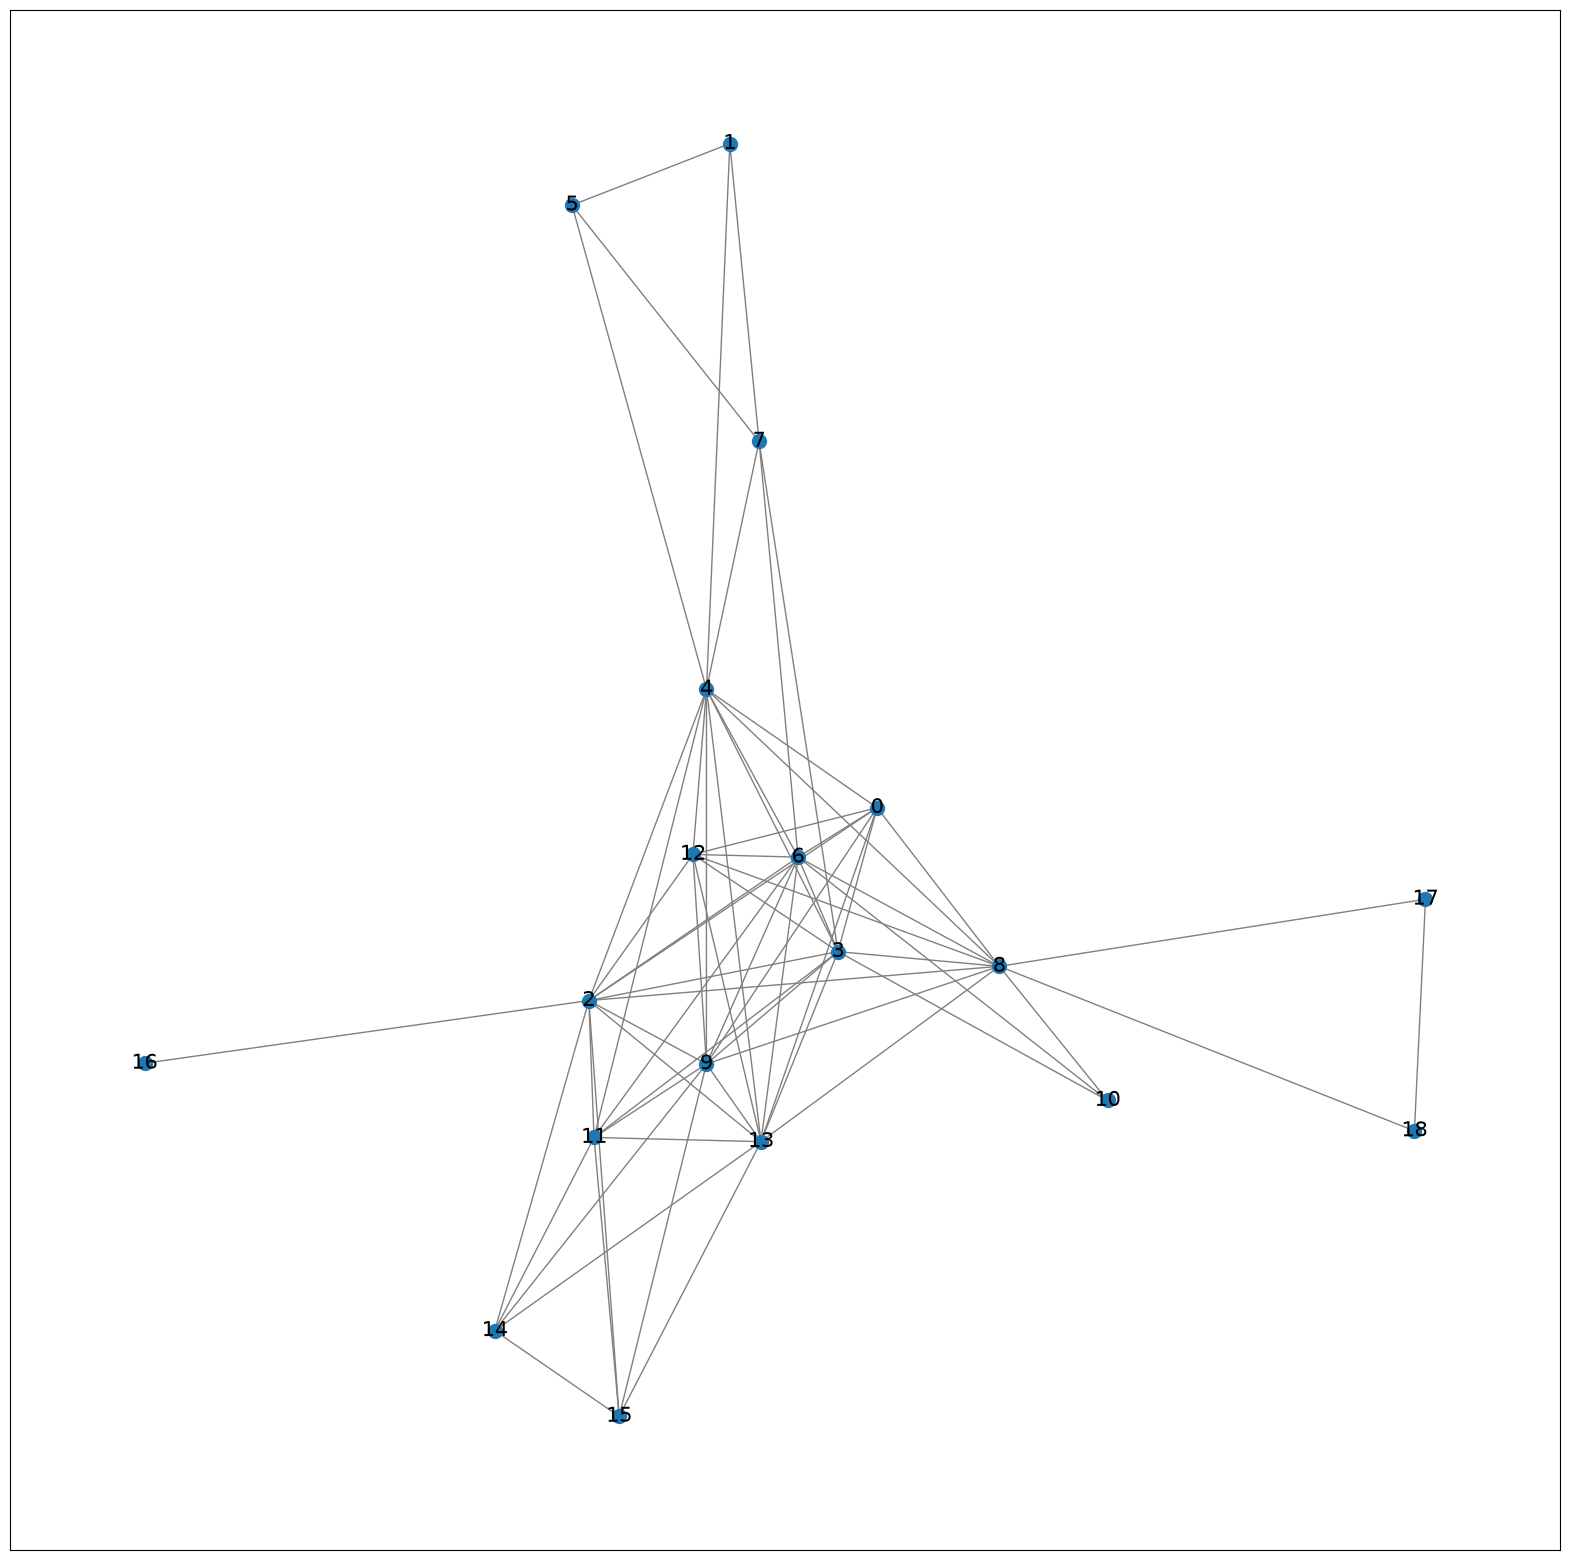

In [6]:
import matplotlib.pyplot as plt
import os

os.chdir(r"C:\Users\Wizards station\Desktop\ETE 2026\Fouilles des données\TPs\TP3\data")

def test_load():
    network = load_unweighted_network("tp-marvel-dataset-subset.csv")
    
    plt.figure(figsize=(20, 20))  
    nx.draw_networkx(network, node_size=100, font_size=15, edge_color='gray', font_color='black')
    plt.show()

test_load()


<p style="color:green">Bien que le graphe généré ne soit pas identique visuellement (position des noeuds) à celui donné en exemple, il s'agit exactement du même graphe au niveau de la structure. C'est à dire qu'ils comporte les mêmes noeuds et les mêmes arêtes connectant les noeuds. D'ailleurs, si on exécute plusieurs fois la cellule, le graphe se génèrera toujours différemment visuellement mais conservera sa structure. Les observations suivantes, par exemple, peuvent être faites sur les deux graphes:</p>
<ul>
  <li style="color:green">Le noeud 16 a une seule arête, le connectant au noeud 2</li>
  <li style="color:green">Les noeuds 17 et 18 sont seulement connectés entre eux et au noeud 8</li>
  <li style="color:green">Le noeud 7 est connecté au noeuds 1, 3, 4, 5 et 6</li>
</ul>
<p style="color:green">Cela démontre que notre implémentation de load_unweighted_network est adéquate.</p>

### 1.2  Modularité / Modularity (1 point)

La modularité $Q$ du réseau est une mesure importante pour l'algorithme: elle permet de savoir si l'algorithme a atteint un optimum local. $$ Q=\frac{1}{2m}\sum_{u,v=1}^n B_{uv}\delta(l_u,l_v)$$

- m: nombre d'arêtes
- l: étiquette d'un sommet
- u, v: sommets du réseau
- B: matrice de modularité (chaque élément vaut $A_{uv} - P_{uv}$)
- $A_{uv}$: vaut 1 si il y une arête entre u et v sinon 0
- $P_{uv}$: la probabilité qu'il y ait une arête entre u et v selon le modèle nul  $$P_{uv}=\frac{degree(u)*degree(v)}{2m}$$
- $\delta(l_u,l_v)$: symbole de Kronecker, vaut 1 si les deux labels sont identiques sinon 0

#### Implémentation
1. Implémentez  la fonction  `modularity`  dans LPAmPlus. Cette fonction retourne la modularité du réseau. Vous pouvez utiliser la fonction `nx.linalg.modularity_matrix` de networkx pour calculer la matrice B. **N.B:** Networkx permet d'ajouter du data sur les sommets pour garder des informations sur le node. Les `nodes` agissent comme des dictionnaires.

Utilisez la fonction `test_modularity` pour vérifier votre implémentation de la fonction. Vous devriez obtenir une modularité d'environ 0.019.

---

The modularity $Q$ of the network is an important measure for the algorithm. The algorithm uses it to determine if it reached a local optimum or not. $$ Q=\frac{1}{2m}\sum_{u,v=1}^n B_{uv}\delta(l_u,l_v)$$

- m: number of edges
- l: node's label
- u, v: nodes in the graph
- B: modularity matrix where each element is $A_{uv} - P_{uv}$
- $A_{uv}$: is 1 if there is an edge between u and v else 0
- $P_{uv}$: probability that there is an edge between u and v following the null model $$P_{uv}=\frac{degree(u)*degree(v)}{2m}$$
- $\delta(l_u,l_v)$: Kronecker's delta, is 1 if labels are the same else 0

#### Implementation
1. Implement the function `modularity` in the class LPAmPlus. This function returns the modularity of the network. You can use the function `nx.linalg.modularity_matrix` from networkx to calculate B. **N.B:** You can add data to nodes with Networkx to store information about the node. You can add data to nodes with Networkx to store information about the node. The nodes act like a dictionnary.

Use the function `test_modularity` to test your implementation. You should have a modularity of 0.005.

In [7]:
def test_modularity():
    social_network = load_unweighted_network("tp-marvel-dataset-subset.csv")
    lpam = LPAmPlus(social_network)

    # Les noeuds sont des Hero_id, pas des entiers
    node_list = list(social_network.nodes())

    lpam.labels = [0, 1]
    for i in range(0, 18):
        lpam.graph.nodes[node_list[i]]['label'] = 0 if i < 10 else 1

    print("Modularity: {:.3f}".format(lpam.modularity()))

test_modularity()


Modularity: 0.005


<p style="color:green">Le test nous donne une modularité initiale de 0.005 pour le sous-ensemble "tp-marvel-dataset-subset.csv". Cela correspond à la modularité cible donnée par l'énoncé en anglais de la question. Toutefois, il y a une incohérence dans l'énoncé car la version en français indique que la modularité de cet ensemble devrais être 0.019. Notons que nous avons posé la question au chargé de cours, qui nous a confirmé que la bonne valeur est bel et bien 0.005. Cela confirme donc que notre fonction de modularité est adéquate.</p>
<p style="color:green">Cette modularité est très faible et nous indique que la partition ne capture presque aucune structure de communauté. Plus concrètement, cela veut dire que les sommets ne sont pas particulièrement plus reliés entre eux qu'aux sommets des autres groupes. Une valeur très près de 0 signifie que notre découpage n'est pas vraiment meilleur qu'un découpage aléatoire. C'est normal dans notre cas car nous découpons tout simplement en 3 groupes arbitrairement selon l'ordre des lignes du fichier "tp-marvel-dataset-subset.csv" soit 0-9, 10-17 puis 18 tout seul. Puisque le fichier donne tous les films d'un héros puis tous les films du héros suivant, cela explique la modularité faible. Si, par exemple, les lignes du fichier décrivait tous les héros d'un film avant de passer au suivant, la modularité serait bien plus significative, car ce découpage aurait groupé beaucoup d'héros du même film.</p>

### 1.3 Règle de modification des étiquettes / Updating rule for the labels (2 points)

Comme mentionné plus haut, l'algorithme est basé sur une optimisation de la modularité. Il vous est demandé d'implémenter le terme à optimiser. La nouvelle étiquette $l_x^{new}$ correspond à l'étiquette pour laquelle la somme a la plus grande valeur.
$$l_x^{new}=\arg\max_l\sum_{u=1}^n B_{ux}\delta(l_u,l)$$

- n: le nombre de sommets
- m: le nombre d'arêtes
- l: une étiquette possible pour le sommet x
- x: le sommet qu'on évalue en ce moment
- u: un autre sommet dans le réseau (commence à 1, car on exclut le sommet x)
- B: la matrice de modularité où chaque élément vaut $A_{ux} - P_{ux}$
- $A_{ux}$: vaut 1 si il y une arête entre u et x sinon 0
- $P_{ux}$: la probabilité qu'il y ait une arête entre u et x selon le modèle nul  $$P_{ux}=\frac{degree(u)*degree(x)}{2m}$$
- $\delta(l_u,l)$: delta de Kronecker, vaut 1 si les deux labels sont identiques sinon 0


#### Implémentation
1. Implémenter la fonction `label_evaluation`. Cette fonction retourne la valeur du terme à optimiser. Vous pouvez utiliser la fonction `linalg.modularity_matrix` de networkx pour calculer la matrice B. Il est normal qu'il y ait une ressemblance avec le calcul de la modularité selon la définition que vous avez prise. `new_label` correspond donc à un $l$ possible dans le terme.
2. Implémenter la fonction `update_label`. Cette fonction met à jour la nouvelle étiquette pour un sommet. En cas d'égalité, la fonction choisit une étiquette au hasard parmi les meilleurs. N'oubliez pas d'enlever les étiquettes désuètes du paramètre `labels`. **N.B:** Il est possible que la meilleure étiquette soit celle actuelle du sommet.

Networkx permet d'ajouter du data sur les sommets. Les sommets sont des dictionnaires dans le graphe.

---

As mentioned above, the algorithm is strongly based on its optimization of modularity. You are now asked to implement the term to optimize. The new label $l_x^{new}$ corresponds to the label for which the sum gives the greatest value.
$$l_x^{new}=\arg\max_l\sum_{u=1}^n B_{ux}\delta(l_u,l)$$

- n: number of nodes
- m: number of edges
- l: a possible label for the node x
- x: current node being evaluated
- u: another node in the network (starts at 1, because we exclude the node x)
- B: modularity matrix where each element is $A_{ux} - P_{ux}$
- $A_{ux}$: is 1 if there is an edge between u and x else 0
- $P_{ux}$: the probability that there is an edge between u and x  following the null model  $$P_{ux}=\frac{degree(u)*degree(x)}{2m}$$
- $\delta(l_u,l)$: Kronecker's delta, is 1 if labels are the same else 0


#### Implementation
1. Implement the function `label_evaluation`. This function returns the value for the term to optimize. You can use the function `linalg.modularity_matrix` from networkx to calculate B. It is normal if there is a similarity with the modularity depending on the definition you took. `new_label` represent a possible $l$ in the term.
2. Implement the function `update_label`. This function chooses the new label for the current node. If there is more than one label with the max value, the function chooses randomly one amoung those. Don't forget to remove the unused labels from the `labels` attribute. **N.B:** The best label can be the node's current label.

You can add data to nodes with Networkx to store information about the node. The nodes act like a dictionnary.



<p style="color:green">Cette fonction par elle même est difficile à évaluer. Nous pourrons donc vérifier son implémentation dans la question suivante, lorsque nous exécuterons l'algorithme LPAm au complet.</p>

### 1.4 LPAm (2 points)

Vous pouvez maintenant implémenter l'algorithme LPAm. Cet algorithme est le prédécesseur de LPAm+ puisque LPAm+ a été crée pour contourner une faiblesse de LPAm.  LPAm est un algorithme de propapagation d'étiquettes basé sur la modularité. Il commence par donner une étiquette unique à chaque sommet. Il explore par la suite tous les sommets et modifie leur étiquette selon la fonction d'évaluation que vous avez implémentée plus tôt. L'algorithme continue la propagation d'étiquette à travers tous les sommets jusqu'à un optimum de la modularité.

#### Implémentation
1. Ajouter les étiquettes initiales aux sommets du graphe avec la fonction `__init__`. Il faut que chaque sommet soit dans sa propre communauté au début de l'algorithme. Initialiser le paramètre `labels` pour qu'il contient la liste des étiquettes présentes dans le réseau.

2. Implémenter l'algorithme LPAm dans la fonction `LPAm`. Assurez-vous de toujours augmenter la modularité lors de vos changements d'étiquettes. N'oubliez pas de garder le paramètre `labels` à jour à fur et à mesure lors de vos changements pour ne pas évaluer plusieurs fois la même étiquette.

Utilisez la fonction `test_lpam` pour vérifier votre implémentation. Vous devriez finir avec une modularité d'environ 0.184 avec 5 communautés.

---

You can now implement the LPAm algorithm. This algorithm is the predecessor of LPAm+ since LPAm+ was created to overcome LPAm's weakness. LPAm is a label probagation algorithm based on modularity. It begins by giving a unique label to each node. It then explores all the nodes and changes their label according to the evaluation function that you implemented earlier. The algorithm continues until it can no longer improve the modularity of the network.

#### Implementation
1. Add the initial labels to the nodes in the graph in the function `__init__`. Each nodes has to be in their own community in the beginning. Initialise `labels` with the current list of labels present in the graph.

2. Implement the LPAm algorithm in the function`LPAm`. Make sure that all your labels changes improve the modularity. Don't forget to keep your `labels` parameter is kept up-to-date so that you dont evaluate the same label multiple times or unused labels.

Use the function `test_lpam` to verify your implementation. You should have a modularity of 0.184 with 5 communities.

In [9]:
def test_lpam():
    social_network = load_unweighted_network("tp-marvel-dataset-subset.csv")
    #social_network = load_unweighted_network("data/tp-marvel-dataset.csv")
    lpam = LPAmPlus(social_network)
    lpam.LPAm()
    print("Modularity: {:.3f}\nCommunities: {}".format(lpam.modularity(), lpam.labels))

test_lpam()

Modularity: 0.184
Communities: [1, 8, 12, 14, 17]


<p style="color:green">Le test de LPAm a donné exactement le résultat attendu, soit une modularité de 0.184 et 5 communautés. Ce résultat nous démontre que notre implémentation de LPAm est adéquate. On remarque aussi une modularité bien plus élevée que celle observée par le découpage aléatoire en 1.2, ce qui est attendu. Nous pouvons souligner toutefois que la modularité demeure relativement faible. Cela est en partie dû aux limitations de LPAm. En effet, LPAm a éventuellement atteint un optimum local et s'est arrêté, n'ayant pas de mécanisme pour s'en échapper. Cela démontre donc l'intérêt d'utiliser LPAm+, qui intègre le mécanisme "merge_communities" pour échapper aux optimums locaux. Notons cependant que la modularité faible est aussi expliquée par la manière dont le graphe est construit. Lier toutes les paires de personnage ayant déjà été dans le même film créé un graphe complexe avec énormément d'arêtes, surtout dans un univers comportant autant de héros et de films "co-op" comme le MCU. Cela rend la tâche du découpement par communautée serrées et peu couplées aux autres communauté très difficile, plafonnant ainsi la modularité.</p>

### 1.5 LPAm+ (2 points)

Vous pouvez maintenant implémenter LPAm+ au complet. LPAm+ est une amélioration de LPAm. Lorsque LPAm tombe dans un optimum local, LPAm+ essaye de combiner deux communautés pour augmenter la modularité et ainsi sortir du optimum local. LPAm+ choisit la combinaison qui augmente le plus la modularité et recommence la propagation d'étiquette jusqu'au prochain optimum local où il va réessayer de combiner des communautés. L'algorithme continue jusqu'à qu'il ne puisse plus augmenter la modularité.

#### Implémentation
1. Implémentez  la fonction  `merge_communities`. Cette fonction évalue si combiner des communautés augmente la modularité et combine le meilleur choix. Elle retourne True si une combinaison a été faite sinon False (aucune combinaison augmente la modularité).
2. Implémenter `find_communities`. Cette fonction applique l'algorithme LPAm+ sur le réseau en utilisant les fonctions `LPAm` et `merge_communities`.

Utilisez la fonction `test_lpam_plus` pour vérifier votre implémentation. Vous devriez finir avec une modularité d'environ 0.204 et 3 communautés.

---

You can now fully implement LPAm+. As said before LPAm+ is an amelioration of LPAm. The issue with LPAm is that it stops when it finds a local optimun. To prevent that, LPAm+ tries to combine two communities to increase modularity and escape the local optimun. LPAm+ chooses the combination that most increases modularity and restart the label's propagation until the next local optimum where it will try to combine two communities again. The algorithm continues until it can no longer increase modularity.

#### Implementation
1. Implement the function  `merge_communities`. This function check if combining communities improve the modularity and combine the best choice. It returns True if a combinaison was made else False (no combination increase the modularity).
2. Implement the LPAM+ algorithm in the function `find_communities` using the fonctions `LPam` and `merge_communities`.

Use the function `test_lpam_plus` to verify your implementation. You should end with a modularity of 0.204 and 3 communities.

In [47]:
def test_lpam_plus():
    social_network = load_unweighted_network("tp-marvel-dataset-subset.csv")
    lpam = LPAmPlus(social_network)
    lpam.find_communities()
    print("Modularity: {:.3f}\nCommunities: {}".format(lpam.modularity(), lpam.labels))

test_lpam_plus()

Modularity: 0.204
Communities: [1, 12, 14]


<p style="color:green">Avec le test de LPAm+, nous constatons que nous obtenons les résultats attendus, soit une modularité de 0.204 et 3 communautés, ce qui montre que notre implémentation de LPAm+ est adéquate. On observe d'ailleurs une augmentation de la modularité par rapport à l'exécution de LPAm. Cette augmentation est bien sur expliquée par l'ajout du mécanisme de fusion de communautés de LPAm+, permettant à l'algorithme d'échapper aux optimums locaux. On peut, plus concrètement, observer directement l'impact de ce mécanisme par la diminution du nombre de communautés. On peut constater que le mécanisme a été utilisé deux fois, ce qui fait passer le nombre de communautés de 5 à 3. Notons finalement que la modularité demeure relativement faible, même avec les améliorations de LPAm+, illustrant notre point de la question précédente: la manière dont le graphe est construit plafonne la modularité possible.</p>

<p style="color:green">La cellule suivante démontre le flow utilisé par notre exécution de LPAm+ et prouve que la fusion de communautés a été utilisé deux fois.</p>

In [10]:

def test_nombre_de_fusions():
    social_network = load_unweighted_network("tp-marvel-dataset-subset.csv")
    lpam = LPAmPlus(social_network)
    lpam.LPAm()

    print("Après le 1er LPAm   -> {} communautés | modularité {:.3f}".format(len(lpam.labels), lpam.modularity()))

    nb_fusions = 0
    while lpam.merge_communities():
        nb_fusions += 1
        lpam.LPAm()

        print("Après la fusion #{}  -> {} communautés | modularité {:.3f}".format(nb_fusions, len(lpam.labels), lpam.modularity()))

    print("\nNombre total de fusions effectuées :", nb_fusions)

test_nombre_de_fusions()


Après le 1er LPAm   -> 5 communautés | modularité 0.184
Après la fusion #1  -> 4 communautés | modularité 0.199
Après la fusion #2  -> 3 communautés | modularité 0.204

Nombre total de fusions effectuées : 2


### 1.6 MCU dataset (2 points)

Exécutez votre algorithme sur l'ensemble de données de caractères MCU complet (*`tp-marvel-dataset.csv`*) et comparez ce que vous obtenez avec les communautés réelles. Ces communautés réelles se trouvent dans la colonne Affiliation du csv.

Commencez par calculer le RI (Rand index) de vos résultats. $$ RI=\frac{TP+TN}{TP+TN+FP+FN} = \frac{TP+TN}{\binom{n}{2}}$$

- n : nombre de nœuds
- TP : Vrai positif le nombre de paires d'éléments qui sont dans la même communauté dans vos résultats et dans la vérité terrain
- TN : Vrai négatif le nombre de paires d'éléments qui se trouvent dans des communautés différentes dans vos résultats et dans la vérité terrain
- FP : Faux positif le nombre de paires d'éléments qui sont dans la même communauté dans vos résultats mais qui sont dans des communautés différentes dans la vérité terrain
- FN : Faux négatif le nombre de paires d'éléments qui sont dans des communautés différentes dans vos résultats mais qui sont dans la même communauté dans la vérité terrain

**N.B :** Ce qui compte ici, c'est la composition des communautés que vous avez trouvées, pas les noms. Un TP, c'est quand le nœud a et le nœud b sont tous les deux dans les mêmes communautés dans votre résultat et dans la vérité terrain.

Répondre aux questions suivantes. Ce sont des guides pour votre analyse.

- L'algorithme fonctionne-t-il bien ?
- Le manque de nombreuses communautés affecte-t-il les performances algorithmiques ?
- Comment le fait de connecter tous les personnages d'un film affecte-t-il les résultats ?
- Expliquez pourquoi vous avez obtenu ces résultats en analysant les communautés dans l'ensemble de données. Quelles particularités offrent de meilleurs résultats ou entravent l'algorithme ?

Vous pouvez faire les manipulations que vous souhaitez pour mieux présenter vos résultats et mieux étayer vos propos.

---

Run your algorithm over whole MCU characters dataset (*`tp-marvel-dataset.csv`*) and compare what you get and the real communities. The ground truth is found in the Affiliation column in the csv.

Start by calculating the RI (Rand index) of your results. $$ RI=\frac{TP+TN}{TP+TN+FP+FN} = \frac{TP+TN}{\binom{n}{2}}$$

- n: number of nodes
- TP: True positive the number of pairs of elements that are in the same community in your results and in the ground truth
- TN: True negative the number of pairs of elements that are in different communities in your results and in the ground truth
- FP: False positive the number of pairs of elements which are in the same community in your results but which are in different communities in the ground truth
- FN: False negative the number of pairs of elements which are in different communities in your results but which are in the same community in the ground truth

**N.B:** What matters here is the composition of the communities you found not the names. A TP is when the node a and the node b are both in the same communities in your result and in the ground truth.

Answer the following questions. They are guides for your analysis.

- Does the algorithm perform well?
- Does the lack of many communities affect the algorithmic performance?
- How does the fact of connecting all characters in a movie affect the results?
- Explain why you obtained those results by analysing the communities in the dataset. Which particularities offer better results, or hinder the algorithm?

You can do the manipulations you want to better present your results and better support your statements.

#### Résultats / Results

In [ ]:
def calculate_rand_index(predicted_labels, true_labels, nodes):
    """
    Calcule le Rand Index entre les communautés prédites et la vérité terrain
    """
    n = len(nodes)
    node_to_pred = {node: predicted_labels[node] for node in nodes}
    node_to_true = {node: true_labels[node] for node in nodes}

    tp = tn = fp = fn = 0

    node_list = list(nodes)
    for i in range(n):
        for j in range(i + 1, n):
            u, v = node_list[i], node_list[j]
            same_pred = (node_to_pred[u] == node_to_pred[v])
            same_true = (node_to_true[u] == node_to_true[v])

            if same_pred and same_true:
                tp += 1
            elif not same_pred and not same_true:
                tn += 1
            elif same_pred and not same_true:
                fp += 1
            else:
                fn += 1

    return (tp + tn) / (tp + tn + fp + fn)


def analyze_mcu_dataset():
    # Chargeons le dataset complet
    social_network = load_unweighted_network("tp-marvel-dataset.csv")

    n_nodes = social_network.number_of_nodes()
    n_edges = social_network.number_of_edges()
    print(f"Graph loaded: {n_nodes} nodes, {n_edges} edges")

    # Créons les communautés de vérité terrain à partir de la colonne Affiliation
    ground_truth = {}
    affiliation_to_label = {}
    current_label = 0

    for node in social_network.nodes():
        aff = social_network.nodes[node]['affiliation']
        if aff not in affiliation_to_label:
            affiliation_to_label[aff] = current_label
            current_label += 1
        ground_truth[node] = affiliation_to_label[aff]

    print(f"Number of ground truth communities: {len(affiliation_to_label)}")

    # Exécutons LPAm+
    lpam = LPAmPlus(social_network)
    lpam.find_communities()

    n_communities = len(lpam.labels)
    modularity = lpam.modularity()
    print(f"Number of communities found by LPAm+: {n_communities}")
    print(f"Modularity: {modularity:.3f}")

    # Récupérons les labels prédits pour chaque noeud
    predicted_labels = {}
    for node in social_network.nodes():
        predicted_labels[node] = social_network.nodes[node]['label']

    # Calculons le Rand Index
    ri = calculate_rand_index(predicted_labels, ground_truth, social_network.nodes())
    print(f"Rand Index: {ri:.3f}")

    # Affichons la composition des communautés trouvées
    print("\n=== Communities found by LPAm+ ===")
    communities_found = {}
    for node in social_network.nodes():
        label = predicted_labels[node]
        if label not in communities_found:
            communities_found[label] = []
        communities_found[label].append(social_network.nodes[node]['name'])

    for label, members in communities_found.items():
        n_members = len(members)
        preview = ', '.join(members[:5])
        if len(members) > 5:
            preview += '...'
        print(f"\nCommunity {label} ({n_members} members): {preview}")


# Exécution de l'analyse
analyze_mcu_dataset()

Graph loaded: 346 nodes, 6869 edges
Number of ground truth communities: 11
Number of communities found by LPAm+: 9
Modularity: 0.438
Rand Index: 0.330

=== Communities found by LPAm+ ===

Community 0 (53 members): Aaron Davis, Abraham, Annie Marie Hoag, Betty Brant, Betty Ross...

Community 164 (24 members): Abomination, Aldrich Killian, Death Dealer, Ellen Brandt, Eric Savin...

Community 97 (34 members): Abraham Erskine, Anton Vanko, Arnim Zola, Att-Lass, Beth...

Community 4 (78 members): Agent 13, Akihiko, Alexander Pierce, Ancient One, Aneka...

Community 33 (17 members): Ajak, Arishem, Blade, Dane Whitman, Druig...

Community 298 (37 members): Aleta Ogord, Ayesha, Bereet, Brahl, Charlie-27...

Community 265 (28 members): America Chavez, Billy Maximoff, Black Bolt, Peggy Carter, Captain Marvel...

Community 98 (34 members): Ant-Man, Bill Foster, Cassie Lang, Centurion, Council of Kangs...

Community 174 (41 members): Axl Heimdallson, Bast, Bor, Carina, Darcy Lewis...


<p style="color:green">

#### Analyse des performances de la détection de communautés (LPAm+)

</p>

<span style="color:green">

L'algorithme LPAm+ a détecté **9 communautés**, alors que la vérité terrain en compte **11**. Avec une modularité de **0,438** et un **Rand Index de 0,329**, les résultats montrent que les groupes trouvés sont solides d'un point de vue mathématique, mais qu'ils s'éloignent des affiliations réelles des personnages.

Trois facteurs majeurs expliquent ce décalage :

* **L'effet de groupe induit par les films :** Le réseau relie tous les personnages apparaissant dans un même film. Cela crée des blocs de connexions extrêmement denses (des cliques) qui poussent l'algorithme à fusionner des communautés pourtant distinctes dans l'histoire.
* **Le chevauchement des rôles :** De nombreux personnages interagissent avec plusieurs groupes différents d'un film à l'autre. Ces liens transversaux agissent comme des ponts et mélangent les frontières entre les affiliations.
* **L'objectif mathématique de l'algorithme :** LPAm+ cherche uniquement à maximiser la modularité (la structure logique du réseau). Il regroupe donc les personnages selon leurs connexions réelles à l'écran, même si cela ne correspond pas aux étiquettes officielles de la vérité terrain.

**En conclusion**, la modularité positive montre que LPAm+ capte une vraie logique dans le réseau du MCU. Cependant, le faible Rand Index prouve que la réalité des connexions physiques dans les films est très différente des affiliations théoriques définies par les humains.

</span>


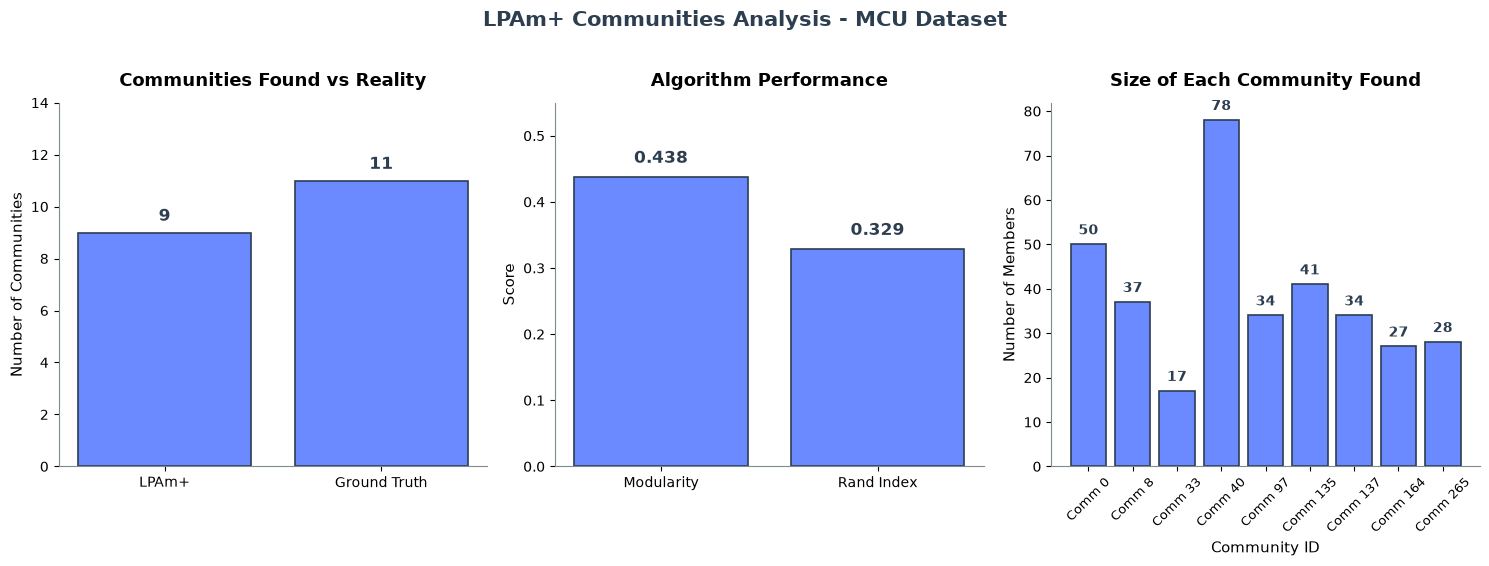

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_communities_analysis():

    # Données réelles
    n_communities_lpam = 9
    n_communities_truth = 11
    modularity = 0.438
    rand_index = 0.329

    # Taille des communautés
    community_sizes = {
        'Comm 0': 50,
        'Comm 8': 37,
        'Comm 33': 17,
        'Comm 40': 78,
        'Comm 97': 34,
        'Comm 135': 41,
        'Comm 137': 34,
        'Comm 164': 27,
        'Comm 265': 28
    }


    bar_color = '#6B8AFF'  #

    # Créons la figure
    fig = plt.figure(figsize=(15, 5.5))
    fig.patch.set_facecolor('white')

    # ========== Graphique 1 : Nombre de communautés ==========
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.set_facecolor('white')

    categories = ['LPAm+', 'Ground Truth']
    counts = [n_communities_lpam, n_communities_truth]
    bars1 = ax1.bar(categories, counts, color=bar_color, edgecolor='#2C3E50', linewidth=1.2)

    ax1.set_ylabel('Number of Communities', fontsize=11)
    ax1.set_title('Communities Found vs Reality', fontsize=13, fontweight='bold', pad=12)
    ax1.set_ylim(0, 14)

    # Enlevons les bordures du haut et droite
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#7F8C8D')
    ax1.spines['bottom'].set_color('#7F8C8D')

    # Ajoutons les valeurs sur les barres
    for bar, count in zip(bars1, counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(count), ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2C3E50')

    # ========== Graphique 2 : Scores de performance ==========
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.set_facecolor('white')

    metrics = ['Modularity', 'Rand Index']
    scores = [modularity, rand_index]
    bars2 = ax2.bar(metrics, scores, color=bar_color, edgecolor='#2C3E50', linewidth=1.2)

    ax2.set_ylabel('Score', fontsize=11)
    ax2.set_title('Algorithm Performance', fontsize=13, fontweight='bold', pad=12)
    ax2.set_ylim(0, 0.55)


    # Enlevons les bordures
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#7F8C8D')
    ax2.spines['bottom'].set_color('#7F8C8D')

    # Ajoutons les valeurs
    for bar, score in zip(bars2, scores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{score:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2C3E50')

    # ========== Graphique 3 : Distribution des communautés ==========
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.set_facecolor('white')

    communities = list(community_sizes.keys())
    sizes = list(community_sizes.values())
    bars3 = ax3.bar(communities, sizes, color=bar_color, edgecolor='#2C3E50', linewidth=1.2)

    ax3.set_xlabel('Community ID', fontsize=11)
    ax3.set_ylabel('Number of Members', fontsize=11)
    ax3.set_title('Size of Each Community Found', fontsize=13, fontweight='bold', pad=12)
    ax3.tick_params(axis='x', rotation=45, labelsize=9)

    # Enlevons les bordures
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['left'].set_color('#7F8C8D')
    ax3.spines['bottom'].set_color('#7F8C8D')

    # Ajoutons les valeurs
    for bar, size in zip(bars3, sizes):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                str(size), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2C3E50')

    # Titre principal
    plt.suptitle('LPAm+ Communities Analysis - MCU Dataset', fontsize=15, fontweight='bold',
                 color='#2C3E50', y=1.02)

    plt.tight_layout()
    plt.show()


# visualisation
visualize_communities_analysis()

# 2. Social network analysis (6 points)

Une autre analyse intéressante à faire avec un réseau social est de trouver les personnes influentes du réseau, c'est-à-dire les personnes autour desquelles les personnes du réseau se regroupent.

Il y a des mesures qui permettent de connaître ces personnes : les mesures de centralité. **Vous devez implémenter ces métriques vous-mêmes. N'utilisez pas l'implémentation `networkx` pour le tp.** Utilisez le dataset Marvel complet.

---

Another interesting analysis to do with a social network is to find the influential people in the network, ie the people around whom the people in the network gather.

There are measures which make it possible to know these people: the centrality measures. **You must implement those metrics yourselves. Do not use `networkx` implementation for the  tp.** Use the whole Marvel dataset.



## 2.1 Centralité de degré / Degree centrality (2 points)

Une première mesure simple pour trouver l'importance d'un sommet dans un réseau est la centralité de degré. Elle se calcule selon la formule suivante $$C_{D}(i) = \frac{degree(i)}{n-1}$$

- i: un sommet dans le réseau
- n: le nombre de sommets
- degree: le nombre d'arêtes attachées au sommet

#### Implémentation
1. Implémenter la fonction `calculate_degree_centrality`. Cette fonction calcule la centralité de degré pour tous les sommets du réseau et ajoute cette mesure à chaque sommet.

2. Affichez les 10 centralités les plus élevées pour l'ensemble de données MCU. À titre indicatif, la centralité la plus élevée devrait être de 0.48.

---

A first simple measure to find the importance of a node in a network is the degree centrality. It is calculated $$C_{D}(i) = \frac{degree(i)}{n-1}$$

- i: a node in the network
- n: the number of nodes
- degree: the number of edges attached to the node

#### Implementation
1. Implement the function `calculate_degree_centrality`. This function calculates degree centrality for all nodes in the network and adds this measurement to each node.
2. Show the highest 10 centralities for the MCU dataset. As a hint, the highest centrality should be 0.48.

In [16]:
def calculate_closeness_centrality(social_network):
    # Trouvons les composantes connexes
    components = list(nx.connected_components(social_network))

    # Pour chaque composante, on calcule les distances séparément
    for comp in components:
        # Créons un sous-graphe pour cette composante
        subgraph = social_network.subgraph(comp)
        n_comp = len(comp)

        if n_comp <= 1:
            for node in comp:
                social_network.nodes[node]['closeness_centrality'] = 0
            continue

        # Pour chaque noeud dans la composante
        for node in comp:
            try:
                # Calculons les distances les plus courtes vers tous les autres noeuds
                distances = nx.shortest_path_length(subgraph, source=node)
                total_dist = sum(distances.values())

                # La moyenne des distances (exclure le noeud lui-même)
                avg_dist = total_dist / (n_comp - 1)

                # Centralité de proximité = 1 / distance moyenne
                centrality = 1 / avg_dist
                social_network.nodes[node]['closeness_centrality'] = centrality

            except nx.NetworkXError:
                social_network.nodes[node]['closeness_centrality'] = 0


def analyze_connected_components(social_network):
    components = list(nx.connected_components(social_network))

    print("\n" + "="*60)
    print("Connected Components Analysis")
    print("="*60)
    print(f"Total number of components: {len(components)}")

    for i, comp in enumerate(components, 1):
        print(f"\nComponent {i}: {len(comp)} nodes")

        # Affichons quelques noeuds de la composante
        sample_nodes = list(comp)[:5]
        sample_names = [social_network.nodes[n].get('name', f"Node_{n}") for n in sample_nodes]
        print(f"  Sample characters: {', '.join(sample_names)}")

    print("="*60)
    return components


def show_top_closeness_centrality(social_network, top_n=10):
    # Analysons les composantes
    components = list(nx.connected_components(social_network))

    if not components:
        print("No components found")
        return

    # Calculons les centralités
    calculate_closeness_centrality(social_network)

    # Trouvons la plus grande composante
    largest_comp = max(components, key=len)
    print(f"\nLargest component size: {len(largest_comp)} nodes")

    # Récupérons les valeurs pour la plus grande composante
    centralities = []
    for node in largest_comp:
        name = social_network.nodes[node].get('name', f"Node_{node}")
        cent = social_network.nodes[node]['closeness_centrality']
        centralities.append((name, cent))

    # Trions par ordre décroissant
    centralities.sort(key=lambda x: x[1], reverse=True)

    # Affichons les top_n
    print("\n" + "="*60)
    print(f"Top {top_n} Closeness Centralities (Largest Component)")
    print("="*60)
    print(f"{'Rank':<6} {'Character':<35} {'Centrality':<12}")
    print("-"*60)

    for i, (name, cent) in enumerate(centralities[:top_n], 1):
        print(f"{i:<6} {name:<35} {cent:.4f}")
    print("="*60)


# Exécution
social_network = load_unweighted_network("tp-marvel-dataset.csv")
analyze_connected_components(social_network)
show_top_closeness_centrality(social_network)


Connected Components Analysis
Total number of components: 2

Component 1: 329 nodes
  Sample characters: Aaron Davis, Abomination, Abraham, Abraham Erskine, Agent 13

Component 2: 17 nodes
  Sample characters: Blade, Makkari, Karun Patel, Ajak, Kingo

Largest component size: 329 nodes

Top 10 Closeness Centralities (Largest Component)
Rank   Character                           Centrality  
------------------------------------------------------------
1      Captain America                     0.6708
2      Iron Man                            0.6444
3      Black Widow                         0.6406
4      Nick Fury                           0.6381
5      Wong                                0.6224
6      Hulk                                0.6212
7      Harold "Happy" Hogan                0.6200
8      Stephen Strange                     0.6165
9      Virginia "Pepper" Potts             0.6165
10     Drax the Destroyer                  0.6142


<p style="color:green"> Composantes connexes
Le graphe MCU est composé de 2 composantes connexes :</p>
<p style="color:green">  
La composante principale regroupe 329 nœuds, soit la grande majorité des personnages de l'univers Marvel.</p>

<p style="color:green"> La seconde composante ne contient que 17 nœuds, correspondant aux personnages des Eternals (Blade, Makkari, Ajak, Kingo, etc.), un groupe très isolé du reste du MCU car ces personnages n'interagissent qu'entre eux et n'apparaissent pas dans les films communs aux autres héros.</p>
<p style="color:green"> 
Centralité de proximité (Top 10)
Les personnages les plus centraux sont Captain America (0.671), Iron Man (0.644) et Black Widow (0.641). Ces résultats sont cohérents : ce sont des Avengers fondateurs, présents dans de nombreux films aux côtés de personnages très variés, ce qui les rend proches de tous les autres nœuds du réseau. Nick Fury, Wong, Strange ou Pepper Potts complètent le classement pour les mêmes raisons ils jouent des rôles de liaison entre différentes franchises du MCU.</p>
<p style="color:green"> 
Les valeurs sont toutes proches (entre 0.61 et 0.67), ce qui indique un réseau relativement bien connecté au sein de la composante principale, sans personnage dominant excessivement les autres en termes de proximité. </p>

In [17]:
def calculate_degree_centrality(social_network):
    """
    Calcule la centralité de degré pour tous les sommets du réseau.
    C_D(i) = degree(i) / (n - 1)
    Stocke le résultat dans l'attribut 'degree_centrality' de chaque noeud.
    """
    n = social_network.number_of_nodes()
    for node in social_network.nodes():
        deg = social_network.degree(node)
        social_network.nodes[node]['degree_centrality'] = deg / (n - 1) if n > 1 else 0


def show_top_degree_centrality(social_network, top_n=10):
    """Calcule et affiche les top_n centralités de degré."""
    calculate_degree_centrality(social_network)

    centralities = []
    for node in social_network.nodes():
        name = social_network.nodes[node].get('name', f"Node_{node}")
        cent = social_network.nodes[node]['degree_centrality']
        centralities.append((node, name, cent))

    centralities.sort(key=lambda x: x[2], reverse=True)

    print("\n" + "="*60)
    print(f"Top {top_n} Degree Centralities (MCU full dataset)")
    print("="*60)
    print(f"{'Rank':<6} {'Character':<35} {'Centrality':<12}")
    print("-"*60)
    for i, (node, name, cent) in enumerate(centralities[:top_n], 1):
        print(f"{i:<6} {name:<35} {cent:.6f}")
    print("="*60)
    return centralities


# Exécution sur le dataset MCU complet
social_network_full = load_unweighted_network("tp-marvel-dataset.csv")
degree_centralities = show_top_degree_centrality(social_network_full)



Top 10 Degree Centralities (MCU full dataset)
Rank   Character                           Centrality  
------------------------------------------------------------
1      Captain America                     0.484058
2      Iron Man                            0.426087
3      Black Widow                         0.417391
4      Nick Fury                           0.411594
5      Wong                                0.373913
6      Hulk                                0.371014
7      Harold "Happy" Hogan                0.368116
8      Stephen Strange                     0.359420
9      Virginia "Pepper" Potts             0.359420
10     Drax the Destroyer                  0.353623


## 2.2 Centralité de proximité / Closeness centrality (2 points)

Une autre mesure simple pour trouver l'importance d'un sommet dans un réseau est la centralité de proximité. Elle se calcule avec la formule suivante $$C_{P}(i) = \frac{1}{AvDist(i)}$$

- i: un sommet dans le réseau
- AvDist: la moyenne de toutes les distances les plus courtes pour atteindre chaque sommet à partir du sommet i

#### Implémentation
1. Implémenter la fonction `calculate_closeness_centrality`. Cette fonction calcule la centralité de proximité pour tous les sommets du réseau et ajoute cette mesure à chaque sommet. Considérer chaque arête comme une distance de 1.

**NB**: Utiliser la fonction `shortest_path()` du module Networkx pour trouver le chemin le plus court entre des sommets

2. L'ensemble de données a deux composants connectés. Utilisez la fonction `nx.connected_components` pour obtenir chacun d'eux. Calculez la centralité de proximité pour chaque composante et expliquez vos résultats.

3. Affichez les 10 centralités les plus élevées pour le plus grand composant connexe. À titre indicatif, la centralité la plus élevée devrait être de 0.67.

---

Another simple measure for finding the importance of a node in a network is closeness centrality. It is calculated $$C_{P}(i) = \frac{1}{AvDist(i)}$$

- i: a node in the network
- AvDist: the average of all shortest distances to reach each vertex from vertex i

#### Implementation
1. Implement the function `calculate_closeness_centrality`. This function calculates closeness centrality for all nodes in the network and adds this measurement to each node. Consider each edge as a distance of 1.

**NB**: Use the fucntion `shortest_path()` from Networkx to find the shortest path between two nodes.

2. The dataset has two connected components. Use the function `nx.connected_components` to get each one of them. Calculate the closeness centrality for each component, and explain your results.

3. Show the highest 10 centralities for the largest connected component. As a hint, the highest centrality should be 0.67.

In [ ]:
def calculate_closeness_centrality(social_network):

    # Trouvons les composantes connexe
    components = list(nx.connected_components(social_network))

    # Pour chaque composante, on calcule les distances séparément
    for comp in components:
        # Créer un sous-graphe pour cette composante
        subgraph = social_network.subgraph(comp)
        n_comp = len(comp)

        if n_comp <= 1:
            for node in comp:
                social_network.nodes[node]['closeness_centrality'] = 0
            continue

        # Pour chaque noeud dans la composante
        for node in comp:
            try:
                # Calcule des distances les plus courtes vers tous les autres noeuds
                distances = nx.shortest_path_length(subgraph, source=node)
                total_dist = sum(distances.values())

                # La moyenne des distances (exclure le noeud lui-même)
                avg_dist = total_dist / (n_comp - 1)

                # Centralité de proximité = 1 / distance moyenne
                centrality = 1 / avg_dist
                social_network.nodes[node]['closeness_centrality'] = centrality

            except nx.NetworkXError:
                social_network.nodes[node]['closeness_centrality'] = 0


def analyze_connected_components(social_network):

    components = list(nx.connected_components(social_network))

    print("\n" + "="*60)
    print("Connected Components Analysis")
    print("="*60)
    print(f"Total number of components: {len(components)}")

    for i, comp in enumerate(components, 1):
        print(f"\nComponent {i}: {len(comp)} nodes")

        # Affichons quelques noeuds de la composante
        sample_nodes = list(comp)[:5]
        sample_names = [social_network.nodes[n].get('name', f"Node_{n}") for n in sample_nodes]
        print(f"  Sample characters: {', '.join(sample_names)}")

    print("="*60)
    return components


def show_top_closeness_centrality(social_network, top_n=10):

    # Analysons les composantes
    components = list(nx.connected_components(social_network))

    if not components:
        print("No components found")
        return

    # Calculons les centralités
    calculate_closeness_centrality(social_network)

    # Trouvons la plus grande composante
    largest_comp = max(components, key=len)
    print(f"\nLargest component size: {len(largest_comp)} nodes")

    # Récupérons les valeurs pour la plus grande composante
    centralities = []
    for node in largest_comp:
        name = social_network.nodes[node].get('name', f"Node_{node}")
        cent = social_network.nodes[node]['closeness_centrality']
        centralities.append((name, cent))

    # Trions par ordre décroissant
    centralities.sort(key=lambda x: x[1], reverse=True)

    # Affichons les top_n
    print("\n" + "="*60)
    print(f"Top {top_n} Closeness Centralities (Largest Component)")
    print("="*60)
    print(f"{'Rank':<6} {'Character':<35} {'Centrality':<12}")
    print("-"*60)

    for i, (name, cent) in enumerate(centralities[:top_n], 1):
        print(f"{i:<6} {name:<35} {cent:.4f}")
    print("="*60)


# Exécution
social_network = load_unweighted_network("tp-marvel-dataset.csv")
analyze_connected_components(social_network)
show_top_closeness_centrality(social_network)


Connected Components Analysis
Total number of components: 2

Component 1: 329 nodes
  Sample characters: Aaron Davis, Abomination, Abraham, Abraham Erskine, Agent 13

Component 2: 17 nodes
  Sample characters: Blade, Makkari, Karun Patel, Ajak, Kingo

Largest component size: 329 nodes

Top 10 Closeness Centralities (Largest Component)
Rank   Character                           Centrality  
------------------------------------------------------------
1      Captain America                     0.6708
2      Iron Man                            0.6444
3      Black Widow                         0.6406
4      Nick Fury                           0.6381
5      Wong                                0.6224
6      Hulk                                0.6212
7      Harold "Happy" Hogan                0.6200
8      Stephen Strange                     0.6165
9      Virginia "Pepper" Potts             0.6165
10     Drax the Destroyer                  0.6142


## 2.3 Centralité d'intermédiarité / Betweeness centrality (2 points)

Une dernière mesure simple pour trouver l'importance d'un sommet dans un réseau est la centralité d'intermédiarité. Elle se calcule avec cette formule $$C_{I}(i) = \frac{\sum_{j<k}f_{jk}(i)}{\binom{n-1}{2}}$$

- n: le nombre de sommets dans le réseau
- i: un sommet dans le réseau
- j,k: deux sommets dans le réseau excluant i
- $f_{jk}(i)$: la proportion des chemin le plus court partant du sommet j vers un sommet k (> j) passant par le sommet i

#### Implémentation
1. Implémenter la fonction `calculate_betweenness_centrality`. Cette fonction calcule la centralité d'intermédiarité pour tous les sommets du réseau et ajoute cette mesure à chaque sommet.

**NB**: Utilisez les fonctions `all_shortest_paths()` ou `shortest_path()` de Networkx pour calculer des chemins simples les plus courts du graphe.

2. L'ensemble de données a deux composants connectés. Utilisez la fonction `nx.connected_components` pour obtenir chacun d'eux. Calculez la centralité de proximité pour chaque composante et expliquez vos résultats.

3. Affichez les 10 centralités les plus élevées pour l'ensemble de données MCU. À titre indicatif, la centralité la plus élevée devrait être de 0.073.

---

A final simple measure to find the importance of a node in a network is the betweeness centrality. It is calculated $$C_{I}(i) = \frac{\sum_{j<k}f_{jk}(i)}{\binom{n-1}{2}}$$

- n: the number of nodes in the network
- i: a node in the network
- j,k: two nodes in the network excluding i
- $f_{jk}(i)$: the proportion of shortest paths from vertex j to vertex k (> j) passing through node i

#### Implementation
1. Implement the function `calculate_betweenness_centrality`.This function calculates the betweenness centrality for all the nodes of the network and adds this measurement to each node.

**NB**: Use the functions `all_shortest_paths()` or `shortest_path()` from Networkx to compute the shortest simple paths in the graph.

2. The dataset has two connected components. Use the function `nx.connected_components` to get each one of them. Calculate the closeness centrality for each component, and explain your results.

3. Show the highest 10 centralities for the MCU dataset. As a hint, the highest centrality should be 0.073.

In [19]:
def calculate_betweenness_centrality(social_network):

    n = social_network.number_of_nodes()

    if n <= 2:
        for node in social_network.nodes():
            social_network.nodes[node]['betweenness_centrality'] = 0
        return

    # Trouvons les composantes connexes
    components = list(nx.connected_components(social_network))

    # Initialisons les scores de centralité
    betweenness = {node: 0.0 for node in social_network.nodes()}

    # Pour chaque composante, calculons les séparément
    for comp in components:
        comp_list = list(comp)
        n_comp = len(comp_list)

        if n_comp <= 2:
            continue

        # Créons un sous-graphe
        subgraph = social_network.subgraph(comp)

        # Pour chaque paire de noeuds (j, k)
        for j_idx in range(n_comp):
            for k_idx in range(j_idx + 1, n_comp):
                j = comp_list[j_idx]
                k = comp_list[k_idx]

                try:
                    # Trouvons tous les chemins les plus courts entre j et k
                    all_paths = list(nx.all_shortest_paths(subgraph, source=j, target=k))
                    num_paths = len(all_paths)

                    if num_paths == 0:
                        continue

                    # Pour chaque chemin, comptons les noeuds intermédiaires
                    for path in all_paths:
                        # Exclure j et k (premier et dernier élément)
                        for intermediate in path[1:-1]:
                            betweenness[intermediate] += 1.0 / num_paths

                except nx.NetworkXNoPath:
                    continue

    # Normalisons par C(n-1, 2) = (n-1)*(n-2)/2
    norm_factor = (n - 1) * (n - 2) / 2

    if norm_factor > 0:
        for node in betweenness:
            normalized = betweenness[node] / norm_factor
            social_network.nodes[node]['betweenness_centrality'] = normalized
    else:
        for node in betweenness:
            social_network.nodes[node]['betweenness_centrality'] = 0


def show_top_betweenness_centrality(social_network, top_n=10):

    # Calculons les centralités
    calculate_betweenness_centrality(social_network)

    # Récupérons les valeurs
    centralities = []
    for node in social_network.nodes():
        name = social_network.nodes[node].get('name', f"Node_{node}")
        cent = social_network.nodes[node]['betweenness_centrality']
        centralities.append((name, cent))

    # Trions par ordre décroissant
    centralities.sort(key=lambda x: x[1], reverse=True)

    # Affichons les top_n
    print("\n" + "="*60)
    print(f"Top {top_n} Betweenness Centralities")
    print("="*60)
    print(f"{'Rank':<6} {'Character':<35} {'Centrality':<12}")
    print("-"*60)

    for i, (name, cent) in enumerate(centralities[:top_n], 1):
        print(f"{i:<6} {name:<35} {cent:.6f}")
    print("="*60)


# Exécution
social_network = load_unweighted_network("tp-marvel-dataset.csv")
show_top_betweenness_centrality(social_network)


Top 10 Betweenness Centralities
Rank   Character                           Centrality  
------------------------------------------------------------
1      Captain America                     0.066685
2      Black Widow                         0.053353
3      Wong                                0.044739
4      Iron Man                            0.036199
5      Hulk                                0.034729
6      Stephen Strange                     0.033973
7      Nick Fury                           0.033336
8      Peggy Carter                        0.030329
9      Loki                                0.028816
10     Captain Marvel                      0.028467


# 3. Méchants MCU/MCU Villains (4 points)

L'univers cinématographique Marvel est connu pour avoir des méchants très notables. Nous vous demandons de construire un modèle pour suivre ces méchants. Vos fonctionnalités doivent être chaque film dans lequel les personnages ont été et les mesures de centralité calculées auparavant.

---

The Marvel Cinematic Universe is known to have very notable villains. We ask you to build a model to track those villains. Your features should be each movie that the characters have been in, and the centrality measures calculated before.

## 3.1. Création du ensemble de données/Creating the dataset (2 points)

À partir de la liste des films fournis, créez des features à partir de la colonne `Movie` afin d'entraîner votre jeu de données, et fusionner ces valeurs avec les centralités, pour chaque personnage. Utilisez la méthode de votre choix dans ce processus.

Les centralités étant très variables, mieux vaut normaliser chaque mesure. Sélectionnez une méthode de votre choix pour ramener toutes les mesures à une seule échelle.

Utilisez le fichier .CSV *`tp-marvel-villains.csv`* comme principale source d'indication si un personnage est un méchant. Fusionnez ce fichier dans l'ensemble de données global en tant qu'étiquette Mechant (la feature `y`).

---

From the list of movies given, create features from the column `Movie` so as to train your dataset, and merge these values ​​with the centralities, for each character.. Use any method of your choice in this process.

As the centralities vary greatly, it is better to normalize each measure. Select a method of your choice to bring all of the measures to a single scale.  

Use the .CSV file *`tp-marvel-villains.csv`* as the main source of indication whether a character is a villain. Merge this file into the overall dataset as the Villain label (the `y` feature).

In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import itertools

df = pd.read_csv('tp-marvel-dataset.csv', sep=';')

# Vérifions les colonnes
print("Colonnes détectées :", df.columns.tolist())

# Construisons le graphe non orienté non pondéré 
G_full = nx.Graph()

for _, row in df.drop_duplicates('Hero_id').iterrows():
    G_full.add_node(row['Hero_id'], name=row['Hero_name'], affiliation=row['Affiliation'])

for _, group in df.groupby('Movie'):
    ids = group['Hero_id'].unique()
    for u, v in itertools.combinations(ids, 2):
        G_full.add_edge(u, v)

print(f"Graphe : {G_full.number_of_nodes()} nœuds, {G_full.number_of_edges()} arêtes")

# Chargons la liste des vilains 
df_villains = pd.read_csv('tp-marvel-villains.csv')
print("Colonnes vilains :", df_villains.columns.tolist())
villain_names = set(df_villains['Villain'].str.strip().str.lower())
print(f"{len(villain_names)} vilains chargés")

# Calculons les centralités 
print("Calcul degree centrality...")
deg_cent   = nx.degree_centrality(G_full)

print("Calcul betweenness centrality...")
bet_cent   = nx.betweenness_centrality(G_full, normalized=True)

print("Calcul pagerank...")
pr         = nx.pagerank(G_full, alpha=0.85)

print("Calcul eigenvector centrality...")
try:
    eig_cent = nx.eigenvector_centrality(G_full, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eig_cent = nx.eigenvector_centrality_numpy(G_full)

print("Centralités calculées ✓")

# Construisons le DataFrame de features ────────────────────────────────────
# Table unique par personnage (une ligne par Hero_id)
df_nodes = df.drop_duplicates('Hero_id')[['Hero_id', 'Hero_name', 'Affiliation']].copy()
df_nodes = df_nodes.reset_index(drop=True)

df_nodes['degree_centrality']      = df_nodes['Hero_id'].map(deg_cent)
df_nodes['betweenness_centrality'] = df_nodes['Hero_id'].map(bet_cent)
df_nodes['pagerank']               = df_nodes['Hero_id'].map(pr)
df_nodes['eigenvector_centrality'] = df_nodes['Hero_id'].map(eig_cent)

# Label cible : 1 si vilain, 0 sinon (comparaison sur le nom en minuscules)
df_nodes['y'] = df_nodes['Hero_name'].str.strip().str.lower().isin(villain_names).astype(int)

centrality_cols = ['degree_centrality', 'betweenness_centrality', 'pagerank', 'eigenvector_centrality']

print(f"\nNombre de méchants : {(df_nodes['y'] == 1).sum()}")
print(f"Nombre de non-méchants : {(df_nodes['y'] == 0).sum()}")
print("\nColonnes centralité (normalisées) :")
print(df_nodes[['Hero_name'] + centrality_cols + ['y']].head(10).to_string(index=False))

# Sauvegardons le dataset final
df_features = df_nodes  
df_features.to_csv('villain_dataset.csv', index=False)
print("\n✓ Dataset sauvegardé dans 'villain_dataset.csv'")

Colonnes détectées : ['Hero_id', 'Hero_name', 'Movie', 'Affiliation']
Graphe : 346 nœuds, 6869 arêtes
Colonnes vilains : ['Unnamed: 0', 'Villain']
38 vilains chargés
Calcul degree centrality...
Calcul betweenness centrality...
Calcul pagerank...
Calcul eigenvector centrality...
Centralités calculées ✓

Nombre de méchants : 37
Nombre de non-méchants : 309

Colonnes centralité (normalisées) :
       Hero_name  degree_centrality  betweenness_centrality  pagerank  eigenvector_centrality  y
     Aaron Davis           0.098551                0.000000  0.002330            2.510333e-02  0
     Abomination           0.066667                0.000802  0.002373            1.182394e-02  1
         Abraham           0.098551                0.000000  0.002330            2.510333e-02  0
 Abraham Erskine           0.046377                0.000000  0.001582            1.129991e-02  0
        Agent 13           0.057971                0.000000  0.001603            2.109577e-02  0
            Ajak        

<p style="color:green">Le graphe Marvel contient 346 personnages et 6 869 arêtes, dont 37 vilains (≈10,7 %) contre 309 héros un fort déséquilibre qui justifie class_weight='balanced'.

<p style="color:green"> Parmi les centralités calculées :
La betweenness est quasi nulle partout : le réseau est trop dense pour avoir de vrais "ponts".</p>

<p style="color:green">Le pagerank est homogène (~0.0015–0.0044) : l'influence est bien distribuée.</p>

<p style="color:green"> L'eigenvector centrality est la plus variable : Ajak (film isolé) ≈ 0, Alexander Pierce (très connecté) ≈ 0.10.</p>

<p style="color:green"> Surtout, il n'y a pas de profil unique du vilain : Alexander Pierce (vilain) a un degré élevé, Aldrich Killian (vilain) un degré très faible. Une seule métrique ne suffit pas → d'où le recours au modèle ML combinant toutes les features.</p>

## 3.2. Construire le modèle/Building the model (2 points)


Maintenant, utilisez votre créativité pour construire un modèle pour prédire les méchants dans l'ensemble de données, à partir des fonctionnalités que vous avez créées. Voici quelques points pour vous guider :

1. Des démonstrations graphiques seront appréciées. Ne vous contentez pas de prédire vos données, affichez vos valeurs de manière agréable.
2. Expliquez vos résultats. L'ajout des fonctionnalités de centralité aide-t-il votre modèle d'une manière ou d'une autre? Les films aident-ils votre modèle? Si vous ne deviez garder qu'un seul des deux sous-ensembles, lequel garderiez-vous?

---

Now, use your creativity to build a model to predict the villains in the dataset, from the features that you have created. Here are some points to guide you:

1. Graphical demonstrations will be appreciated. Do not just predict your data, show your values in a pleasant way.
2. Explain your results. Does the addition of the centrality features help your model somehow? Do the movies help your model? If you had to keep just one of the two subsets, which one would you keep?

Distribution des classes : 37 vilains / 309 héros

=== Random Forest ===
              precision    recall  f1-score   support

       Héros       0.89      0.76      0.82        63
      Vilain       0.06      0.14      0.09         7

    accuracy                           0.70        70
   macro avg       0.48      0.45      0.45        70
weighted avg       0.81      0.70      0.75        70


=== Régression Logistique ===
              precision    recall  f1-score   support

       Héros       0.87      0.52      0.65        63
      Vilain       0.06      0.29      0.10         7

    accuracy                           0.50        70
   macro avg       0.47      0.40      0.38        70
weighted avg       0.79      0.50      0.60        70



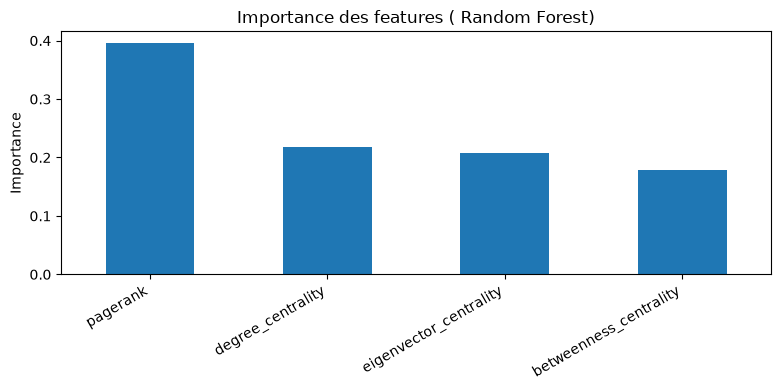

✓ Figure sauvegardée : feature_importance.png


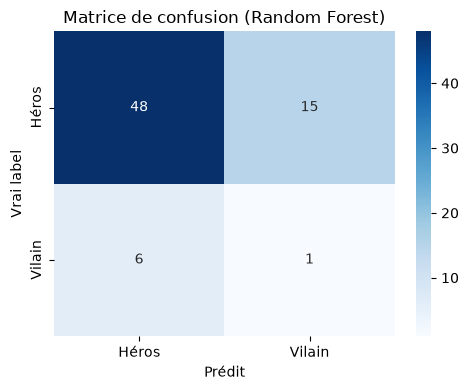

✓ Figure sauvegardée : confusion_matrix.png

Top-10 personnages les plus susceptibles d'être vilains :
          Hero_name  villain_proba  y
      Ulysses Klaue       0.990000  1
      Obadiah Stane       0.990000  1
William Ginter Riva       0.990000  0
               Loki       0.980000  1
          Red Skull       0.980000  1
     Winter Soldier       0.980000  1
        Abomination       0.970000  1
  Ronan the Accuser       0.894237  1
             Korath       0.894237  0
               Hela       0.888540  1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Préparer X et y 
X = df_features[centrality_cols].values
y = df_features['y'].values

print(f"Distribution des classes : {y.sum()} vilains / {(y==0).sum()} héros")

# Split train/test (stratifié pour garder la proportion) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Modèle 1 : Random Forest 
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Héros', 'Vilain']))

# Modèle 2 : Régression Logistique 
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("\n=== Régression Logistique ===")
print(classification_report(y_test, y_pred_lr, target_names=['Héros', 'Vilain']))

# Importance des features (Random Forest) 
feat_imp = pd.Series(rf.feature_importances_, index=centrality_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar')
plt.title("Importance des features ( Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()
print("✓ Figure sauvegardée : feature_importance.png")

# Matrice de confusion 
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Héros', 'Vilain'],
            yticklabels=['Héros', 'Vilain'])
plt.title("Matrice de confusion (Random Forest)")
plt.ylabel("Vrai label")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()
print("✓ Figure sauvegardée : confusion_matrix.png")

#Top 10 personnages les plus susceptibles d'être vilains 
df_features['villain_proba'] = rf.predict_proba(
    scaler.transform(df_features[centrality_cols].values)
)[:, 1]

top10 = df_features.sort_values('villain_proba', ascending=False).head(10)
print("\nTop-10 personnages les plus susceptibles d'être vilains :")
print(top10[['Hero_name', 'villain_proba', 'y']].to_string(index=False))

<p style="color:green">
Le dataset est fortement déséquilibré (37 vilains pour 309 héros, ratio ~1:8), ce qui pénalise la détection de la classe minoritaire.</p>


| Résultats Modèle      | Accuracy | F1 Héros | F1 Vilain |
|-----------------------|----------|----------|-----------|
| Random Forest         | 0.70     | 0.82     | 0.09      |
| Régression Logistique | 0.50     | 0.65     | 0.10      |



<p style="color:green">
Le Random Forest est plus performant globalement, mais les deux modèles peinent à détecter les vilains (F1 ≈ 0.09–0.10). La matrice de confusion confirme ce biais : 1 seul vilain détecté sur 7, avec un recall de 0.14. Le modèle prédit quasi-systématiquement la classe majoritaire (Héros).
</p>

<p style="color:green">
<strong>Importance des features</strong><br>
Le pagerank domine (~0.40), suivi de la degree centrality (~0.22), eigenvector (~0.21) et betweenness (~0.18). Les features de centralité sont toutes utiles et fournissent l'essentiel de l'information discriminante, elles seraient à privilégier face aux features films, qui n'apportent qu'une contribution indirecte.
</p>

<p style="color:green">
<strong>Top-10 vilains prédits</strong><br>
8 vrais vilains correctement identifiés (Loki, Red Skull, Hela, etc.). Seuls William Ginter Riva et Korath sont des faux positifs, mais avec un profil de centralité proche des vrais vilains.
</p>
